# **Based Agent in LangGraph**

## **State, Node, and Edges definition**

In [2]:
from dotenv import load_dotenv
from typing import Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama


load_dotenv()

llm = init_chat_model(
    "anthropic:claude-3-5-sonnet-latest"
)
ollama = ChatOllama(
    model="qwen3.8:latest",  # Your specified model
    temperature=0,           # Deterministic responses
)


# Define a Pydantic model for structured output
class MessageClassifier(BaseModel):
    message_type: Literal["emotional", "logical"] = Field(
        ...,
        description="Classify if the message requires an emotional (therapist) or logical response."
    )


# Define a TypedDict for the state
class State(TypedDict):
    messages: Annotated[list, add_messages]
    message_type: str | None


# Node function to classify the message
def classify_message(state: State):
    # Get the most recent user message
    last_message = state["messages"][-1]
    
    # Create a classifier LLM with structured output
    #classifier_llm = llm.with_structured_output(MessageClassifier)
    classifier_llm = ollama.with_structured_output(MessageClassifier)
    
    # Call the LLM to classify the message
    result = classifier_llm.invoke([
        {
            "role": "system",
            "content": """Classify the user message as either:
            - 'emotional': if it asks for emotional support, therapy, deals with feelings, or personal problems
            - 'logical': if it asks for facts, information, logical analysis, or practical solutions
            """
        },
        {"role": "user", "content": last_message.content}
    ])
    
    # Return the classification result (updates the state)
    return {"message_type": result.message_type}  


# Node function to route to the appropriate agent based on classification
def router(state: State):
    # Get the message type from state (default to "logical" if None)
    message_type = state.get("message_type", "logical")
    
    # Route to the appropriate agent
    if message_type == "emotional":
        return {"next": "therapist"}
    
    return {"next": "logical"}


# Node function for the therapist agent
def therapist_agent(state: State):
    # Get the user's last message
    last_message = state["messages"][-1]
    
    # Prepare conversation with system prompt
    messages = [
        {"role": "system",
         "content": """You are a compassionate therapist. Focus on the emotional aspects of the user's message.
                        Show empathy, validate their feelings, and help them process their emotions.
                        Ask thoughtful questions to help them explore their feelings more deeply.
                        Avoid giving logical solutions unless explicitly asked."""
         },
        {
            "role": "user",
            "content": last_message.content
        }
    ]
    
    # Get response from LLM
    #reply = llm.invoke(messages)
    reply = ollama.invoke(messages)
    
    # Return the assistant's response (appended to messages)
    return {"messages": [{"role": "assistant", "content": reply.content}]}


# Node function for the logical agent
def logical_agent(state: State):
    # Get the user's last message
    last_message = state["messages"][-1]
    
    # Prepare conversation with system prompt
    messages = [
        {"role": "system",
         "content": """You are a purely logical assistant. Focus only on facts and information.
            Provide clear, concise answers based on logic and evidence.
            Do not address emotions or provide emotional support.
            Be direct and straightforward in your responses."""
         },
        {
            "role": "user",
            "content": last_message.content
        }
    ]
    
    # Get response from LLM
    #reply = llm.invoke(messages)
    reply = ollama.invoke(messages)
    
    # Return the assistant's response (appended to messages)
    return {"messages": [{"role": "assistant", "content": reply.content}]}



## **Graph with conditional edge**

In [3]:
# Build the state graph
graph_builder = StateGraph(State)

# Add nodes and edges to the graph
graph_builder.add_node("classifier", classify_message)
graph_builder.add_node("router", router)
graph_builder.add_node("therapist", therapist_agent)
graph_builder.add_node("logical", logical_agent)

graph_builder.add_edge(START, "classifier")
graph_builder.add_edge("classifier", "router")

graph_builder.add_conditional_edges(
    "router",
    lambda state: state.get("next"),
    {"therapist": "therapist", "logical": "logical"}
)

graph_builder.add_edge("therapist", END)
graph_builder.add_edge("logical", END)

graph = graph_builder.compile()


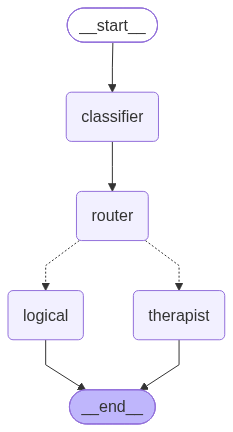

In [4]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization is optional; graph execution still works.")
    print(type(e).__name__, e)

In [ ]:
def run_chatbot():
    state = {"messages": [], "message_type": None}

    while True:
        user_input = input("Message: ")
        if user_input == "exit":
            print("Bye")
            break

        state["messages"] = state.get("messages", []) + [
            {"role": "user", "content": user_input}
        ]

        state = graph.invoke(state)

        if state.get("messages") and len(state["messages"]) > 0:
            last_message = state["messages"][-1]
            print(f"Assistant: {last_message.content}")


if __name__ == "__main__":
    run_chatbot()